# Estimating AR(p) coefficients via OLS

An AR(p) process $Y_t = \alpha_1 Y_{t-1} + \alpha_2 Y_{t-2} + \cdots + \alpha_p Y_{t-p} + \epsilon_t$ is just a linear regression where the features are lagged values of $Y$.

OLS gives us the closed-form estimate $\hat{\alpha} = (X^T X)^{-1} X^T y$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from AR_specs import P, SIGMA

### Load data and true alphas

In [2]:
ar_data = pd.read_csv('saved_data/ar_data.csv', index_col='t')
Y_full = ar_data['Y'].to_numpy()

alpha_df = pd.read_csv('saved_data/alphas.csv', index_col='lags')
true_alphas = alpha_df['alpha'].to_numpy()

print(f'Loaded {len(Y_full)} data points, AR order P={P}')
print(f'True alphas: {true_alphas}')

Loaded 100001 data points, AR order P=5
True alphas: [-0.44775626  0.78521643 -0.21437406 -0.48722836  0.23731253]


### Build the lagged feature matrix

For each time $t \geq P$, the feature row is $[Y_{t-1}, Y_{t-2}, \ldots, Y_{t-P}]$ and the target is $Y_t$.

In [3]:
def build_lag_matrix(Y, p):
    """Return (X, y) where X[i] = [Y[i+p-1], Y[i+p-2], ..., Y[i]] and y[i] = Y[i+p]."""
    n = len(Y) - p
    X = np.zeros((n, p))
    for lag in range(1, p + 1):
        X[:, lag - 1] = Y[p - lag : p - lag + n]
    y = Y[p:]
    return X, y

X_all, y_all = build_lag_matrix(Y_full, P)
print(f'Feature matrix shape: {X_all.shape}, target shape: {y_all.shape}')

Feature matrix shape: (99996, 5), target shape: (99996,)


### Train / test split (80/20 in order)

In [4]:
split = int(len(y_all) * 0.8)

X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 79996 samples
Test:  20000 samples


### OLS estimation

$\hat{\alpha} = (X^T X)^{-1} X^T y$

In [5]:
alpha_hat = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)

comparison = pd.DataFrame({
    'True alpha': true_alphas,
    'OLS estimate': alpha_hat,
    'Error': alpha_hat - true_alphas,
}, index=[f'alpha_{i+1}' for i in range(P)])

comparison

,True alpha,OLS estimate,Error
alpha_1,-0.447756,-0.443380,0.004376
alpha_2,0.785216,0.785587,0.000371
alpha_3,-0.214374,-0.220943,-0.006569
alpha_4,-0.487228,-0.485897,0.001331
alpha_5,0.237313,0.241566,0.004254


### 1-step-ahead predictions on the test set

In [6]:
y_pred = X_test @ alpha_hat
residuals = y_test - y_pred
test_mse = float(np.mean(residuals ** 2))

print(f'Test MSE: {test_mse:.6f}')

Test MSE: 1.000042


### Evaluation plots

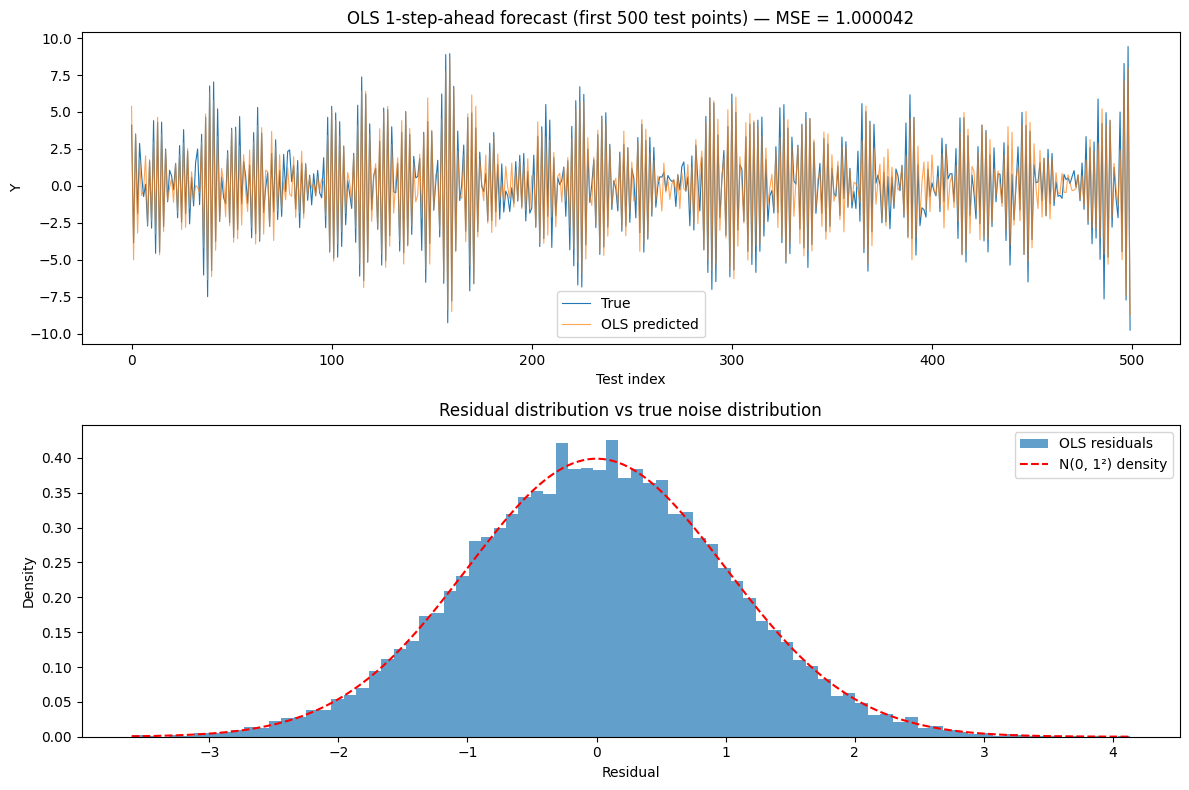

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Time series: true vs predicted (first 500 test points)
n_show = 500
ax = axes[0]
ax.plot(range(n_show), y_test[:n_show], linewidth=0.8, label='True')
ax.plot(range(n_show), y_pred[:n_show], linewidth=0.8, alpha=0.7, label='OLS predicted')
ax.set_xlabel('Test index')
ax.set_ylabel('Y')
ax.set_title(f'OLS 1-step-ahead forecast (first {n_show} test points) — MSE = {test_mse:.6f}')
ax.legend()

# Residual histogram
ax = axes[1]
ax.hist(residuals, bins=80, density=True, alpha=0.7, label='OLS residuals')
xs = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(xs, (1 / (SIGMA * np.sqrt(2 * np.pi))) * np.exp(-xs**2 / (2 * SIGMA**2)),
        'r--', linewidth=1.5, label=f'N(0, {SIGMA}²) density')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual distribution vs true noise distribution')
ax.legend()

plt.tight_layout()
plt.show()

### Save results for comparison with RNN notebook

In [8]:
results = pd.DataFrame({
    'y_true': y_test,
    'y_pred_ols': y_pred,
})
results.to_csv('saved_data/ols_results.csv', index=False)

mse_df = pd.DataFrame({'method': ['OLS'], 'test_mse': [test_mse]})
mse_df.to_csv('saved_data/ols_mse.csv', index=False)

print('Saved OLS predictions and MSE to saved_data/')

Saved OLS predictions and MSE to saved_data/
